FINTECH CHURN INTELLIGENCE

Churn Prediction & Risk Analysis

Objective:
- Build a baseline churn prediction model
- Compare Logistic Regression and Random Forest
- Identify key churn drivers
- Generate business recommendations

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
df = pd.read_csv("../01_Data/Churn_Modelling.csv")

df = df.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Geography"] = le.fit_transform(df["Geography"])

X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (8000, 10)
Test Shape : (2000, 10)


In [4]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:,1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_acc,4))
print("ROC-AUC  :", round(lr_auc,4))

Logistic Regression Results
---------------------------
Accuracy : 0.805
ROC-AUC  : 0.771


In [5]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:,1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_acc,4))
print("ROC-AUC  :", round(lr_auc,4))

Logistic Regression Results
---------------------------
Accuracy : 0.805
ROC-AUC  : 0.771


In [6]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_acc,4))
print("ROC-AUC  :", round(rf_auc,4))

Random Forest Results
---------------------
Accuracy : 0.865
ROC-AUC  : 0.8467


In [7]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "ROC_AUC": [lr_auc, rf_auc]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.805,0.771044
1,Random Forest,0.865,0.846666


In [8]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "ROC_AUC": [lr_auc, rf_auc]
})

comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.805,0.771044
1,Random Forest,0.865,0.846666


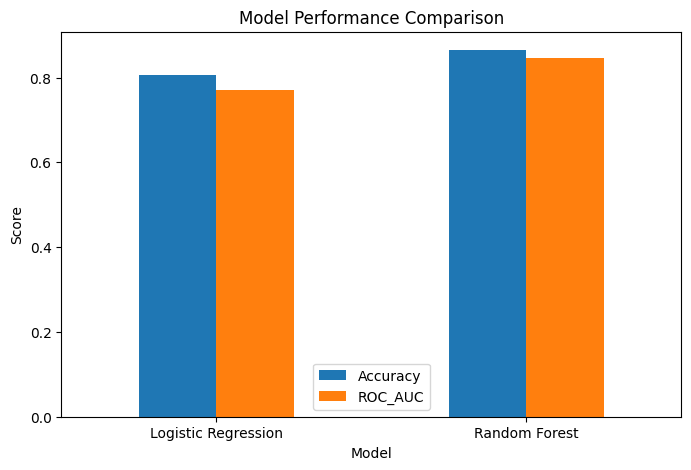

In [9]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

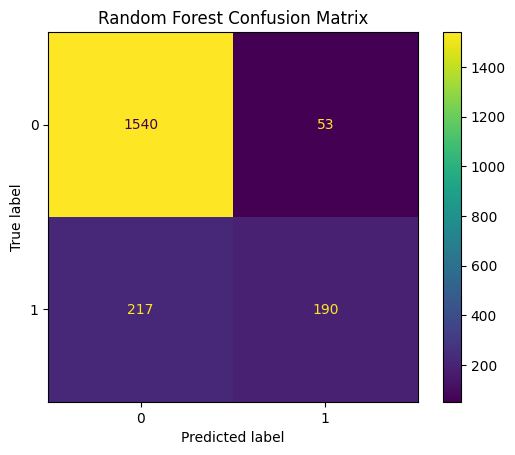

In [10]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [11]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
3,Age,0.239784
9,EstimatedSalary,0.147620
0,CreditScore,0.143640
5,Balance,0.141030
6,NumOfProducts,0.129349
4,Tenure,0.081846
8,IsActiveMember,0.039811
1,Geography,0.038290
7,HasCrCard,0.019757
2,Gender,0.018873


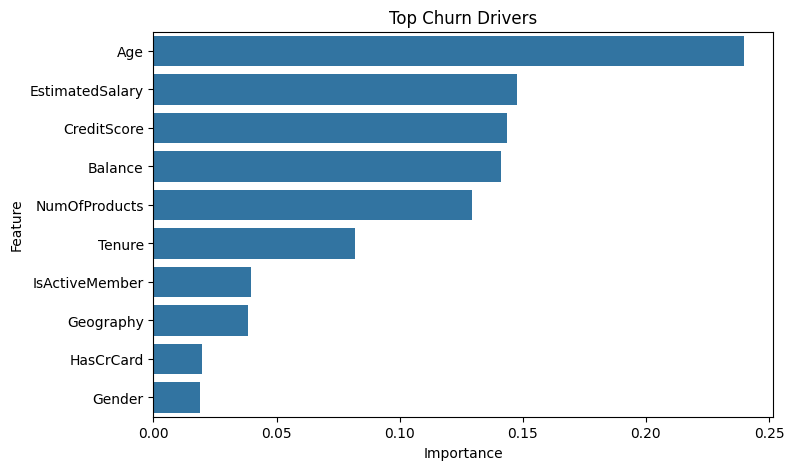

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Churn Drivers")

plt.show()

In [13]:
# CELL 9 — Final Summary

print("="*60)
print("FINTECH CHURN MODEL RESULTS SUMMARY")
print("="*60)

print(f"\nLogistic Regression AUC : {lr_auc:.4f}")
print(f"Random Forest AUC      : {rf_auc:.4f}")

if rf_auc > lr_auc:
    print("\nWinner Model: Random Forest")
else:
    print("\nWinner Model: Logistic Regression")

print("\nTop 5 Churn Drivers:")

top5 = importance_df.sort_values(
    "Importance",
    ascending=False
).head(5)

for i, row in enumerate(top5.itertuples(), 1):
    print(f"{i}. {row.Feature}")

print("\nBusiness Recommendation:")
print("- Prioritize retention campaigns for high-risk customers")
print("- Focus on inactive members and low-product customers")
print("- Use churn probability scores for CRM targeting")

print("\nOutput Generated:")
print("- at_risk_customers.csv")
print("- ROC Curve Comparison")
print("- Confusion Matrix")
print("- Feature Importance Chart")

print("\nProject Completed Successfully")
print("="*60)

FINTECH CHURN MODEL RESULTS SUMMARY

Logistic Regression AUC : 0.7710
Random Forest AUC      : 0.8467

Winner Model: Random Forest

Top 5 Churn Drivers:
1. Age
2. EstimatedSalary
3. CreditScore
4. Balance
5. NumOfProducts

Business Recommendation:
- Prioritize retention campaigns for high-risk customers
- Focus on inactive members and low-product customers
- Use churn probability scores for CRM targeting

Output Generated:
- at_risk_customers.csv
- ROC Curve Comparison
- Confusion Matrix
- Feature Importance Chart

Project Completed Successfully
